🧠 Operations

1- Merge : merge() is like SQL JOIN — it combines rows from two DataFrames based on one or more common columns or indexes.

*    Function = pd.merge(left , right , on = 'key' , how = 'inner'/'outer'/'left'/'right')

*    Analogy = SQL JOIN


*   Works on = DataFrames
*   Based on = Common Columns or indexes



*   purpose = Combine datasets on keys

2- Join : join() is a shortcut for merging based on index, or optionally on a key column.It's less flexible than merge() but often cleaner for index-based joins.


*   Function = df1.join(df2 , how = 'left')

*   Analogy = Simplified merge (SQL JOIN)

*   works on = DataFrames
*   Based on = Index or key column


*   purpose = Combine columns from two DataFrames

🧩 Note: 'join' uses the index by default, unlike 'merge' which uses columns.

3- Concatenate : concat() stacks multiple Series/DataFrames together — either vertically (rows) or horizontally (columns).


*   Function = pd.concat([df1 , df2] , axis = 0/1)

*   Analogy = “Stacking”

*   works on = Series/DataFrames
*   Based on = Axis (rows = 0 or columns = 1)


*   purpose = Append datasets along rows or columns

In [2]:
import numpy as np
import pandas as pd

In [3]:
courses = pd.read_csv('/content/drive/MyDrive/CSV_files/courses.csv')        # courses in which students enrolled
students = pd.read_csv('/content/drive/MyDrive/CSV_files/students.csv')      # students enrolled in the courses
nov = pd.read_csv('/content/drive/MyDrive/CSV_files/reg-month1.csv')         # students enrolled in courses in 'november' month
dec = pd.read_csv('/content/drive/MyDrive/CSV_files/reg-month2.csv')         # students enrolled in courses in 'december' month

matches = pd.read_csv('/content/drive/MyDrive/CSV_files/matches.csv')
delivery = pd.read_csv('/content/drive/MyDrive/CSV_files/deliveries.csv')

# ⚡ Concatenate

In [4]:
# pd.concat([]) : to stack the series/dataFrames in horizontal/vertical manner
pd.concat([nov , dec])      # registration data for 'nov' and 'dec' months dataFrames

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [5]:
# ignore_index(True) : to ignore the repeating indexes and get unique indexes
regs = pd.concat([nov , dec] , ignore_index = True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


### ***Note*** : 'df1.append(df2)' is no longer available in Pandas

In [6]:
# Multi-index DataFrame
multi = pd.concat([nov , dec] , keys = ['Nov' , 'Dec'])    # 'Nov' and 'Dec' as indexes are added with original integer indexes
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [7]:
# working with multi-index dataFrame

# fetch the labelled based index
multi.loc['Dec']

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [8]:
# fetch the data of the specific row of the labelled index
multi.loc[('Nov' , 4)]    # tuple() of 'labelled-index' and 'integer-index'

,Nov
,4
student_id,16
course_id,9


## Horizontal concatenation : axis = 1 -> column-wise

✅ Note : By default Series/Datasets concatenate Vertically
- When concatenating Series/DataFrames vertically using pd.concat() with axis=0, the DataFrames do not need to have the same number of columns because pd.concat() will align the Series/DataFrames based on their column names and fill any missing values with NaN in the resulting DataFrame.

In [9]:
pd.concat([nov , dec] , axis = 1)   # side-by-side stacking

# Note : Dataset which has more number of rows will show same number of rows in 'resulting Data' by putting 'NaN' values in lesser rows Dataset

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## Concatenating Series and DataFrame
- When you concatenate a Series with a DataFrame along axis = 0( row-wise ), the Series will be treated as a single row DataFrame. The concatenation will align based on the column names (or index if no column names are shared)

1- Matched indexes of Series and columns of DataFrame

In [10]:
# Create a sample DataFrame and Series
df_sample = pd.DataFrame({'col1': [1, 2], 'col2': [3, 4]})     # DataFrame with 2 columns as 'col1' and 'col2' using dictionary
series_sample = pd.Series([5, 6], index=['col1', 'col2'])      # Series with 1 column and labelled indexes as 'col1' and 'col2'

# Concatenate the Series and DataFrame along axis=0 ( vertical stacking )
concatenated_df = pd.concat([df_sample, series_sample.to_frame().T], ignore_index=True)

# original DataFrame
print("Original DataFrame:")
display(df_sample)

# Original Series
print("\nOriginal Series:")
display(series_sample)

# concatenated Output
print("\nConcatenated DataFrame:")
display(concatenated_df)

Original DataFrame:


,col1,col2
0,1,3
1,2,4



Original Series:


,0
col1,5
col2,6



Concatenated DataFrame:


,col1,col2
0,1,3
1,2,4
2,5,6


2- Unmatcehd indexes of Series and columns of DataFrame

In [11]:
# Create a sample DataFrame
df_sample = pd.DataFrame({'col1': [1, 2], 'col2': [3, 4]})

# Create a Series with unmatched index names
series_sample = pd.Series([5, 6], index=['col_a', 'col_b'])

# Concatenate the Series and DataFrame along axis = 0 ( row-wise )
concatenated_unmatched_df = pd.concat([df_sample, series_sample.to_frame().T], ignore_index=True)   # 'series_sample.to_frame().T' : Before concatenation, the Series is converted into a DataFrame using to_frame(). By default, this would create a DataFrame with one column. '.T' is then used to transpose this DataFrame, turning the index labels ('col_a', 'col_b') into column names and the values (5, 6) into a single row.

# Original DataFrame
print("Original DataFrame:")
display(df_sample)

# Original Series
print("\nOriginal Series (unmatched index):")
display(series_sample)

# Concatenated output
print("\nConcatenated DataFrame (unmatched index):")
display(concatenated_unmatched_df)

Original DataFrame:


,col1,col2
0,1,3
1,2,4



Original Series (unmatched index):


,0
col_a,5
col_b,6



Concatenated DataFrame (unmatched index):


,col1,col2,col_a,col_b
0,1.0,3.0,NaN,NaN
1,2.0,4.0,NaN,NaN
2,NaN,NaN,5.0,6.0


Horizontal ( column-wise ) concatenation

In [12]:
# axis = 1 -> Horizontal concat ( column-wise )
pd.concat([df_sample , series_sample.to_frame().T] , ignore_index = True , axis = 1)

,0,1,2,3
0,1,3,5.0,6.0
1,2,4,NaN,NaN


# ⚡ Merge
- Inner Join
- Outer Join ( Full Join )
- Left Join
- RIght Join

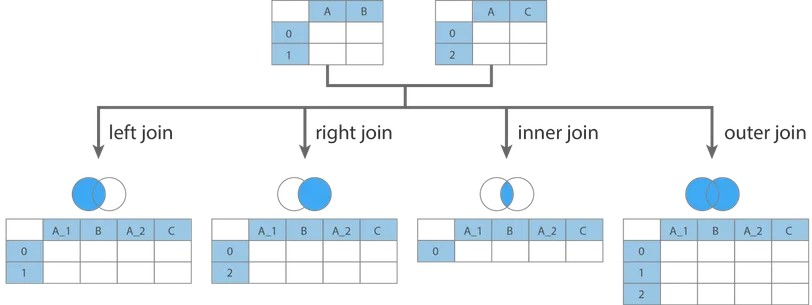

In [13]:
# inner join -> intersection of two DataFrames
# Join on the basis of common column / index
students.merge(regs , on = 'student_id'  , how = 'inner')         # on basis of 'student_id' inner join happened and only unique 'student_id' is present in the output with their multiple course regitrations

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [14]:
# left join -> intersection + left DataFrame content comes completely
courses.merge(regs , on = 'course_id' , how = 'left')                   # left joining on basis of 'course_id' column

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [15]:
# right join -> intersection + right DataFrame content comes completely
students.merge(regs, on = 'student_id'  , how = 'right')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [16]:
# outer join (full join / union) -> both DataFrames contents will come completely
students.merge(regs , how = 'outer' , on = 'student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
5,3,Parveen Bhalla,3.0,3.0
6,3,Parveen Bhalla,3.0,5.0
7,4,Marlo Dugal,14.0,NaN
8,5,Kusum Bahri,6.0,NaN
9,6,Lakshmi Contractor,10.0,NaN


### ✅ Note : You don't need to perform 'left' and 'right' join for your questions, rather just shift the order of your DataFrames

# Practice Questions

In [17]:
# 1. find total revenue generated
revenue = courses.merge(regs , how = 'inner' , on = 'course_id')
print(revenue['price'].sum())

154247


In [18]:
# 2. find the month by month revenue

# Method - 1
print(f'November month Revenue : ' , courses.merge(nov , how = 'inner' , on = 'course_id')['price'].sum())
print(f'December month Revenue : ' , courses.merge(dec , how = 'inner' , on = 'course_id')['price'].sum() , '\n')

# Method - 2
temp_df = pd.concat([nov , dec] , keys = ['Nov' , 'Dec']).reset_index()                        # making a combined DataFrame by concatenating 'nov' and 'dec' DataFrames | reset_index() will convert original indexes into complete indexes where for every row -> 'nov' and 'dec' month will be shown
temp_df.merge(courses , how = 'inner' , on = 'course_id').groupby('level_0')['price'].sum()    # merging and then 'groupby()' on basis of 'level_0' column i.e. months('Nov' and 'Dec') and then selecting 'price' column for both 'nov' and 'dec' group and summing the prices of courses

November month Revenue :  89175
December month Revenue :  65072 



,price
level_0,
Dec,65072
Nov,89175


In [19]:
# 3. Print the registration table with 'name' , 'course' and 'price' columns as well

# Method-1
temp_df = regs.merge(students , how = 'left' , on = 'student_id')                         # joining 'regs' and 'students' on 'student_id' with 'left join'
new_regs_table = temp_df.merge(courses , how = 'left' , on = 'course_id')                 # joining 'temp_df' and 'courses' on 'course_id' with 'left join'

print(new_regs_table[['name' , 'course_name' , 'price']] , '\n')                          # printing only required columns i.e. ['name' , 'course_name' , 'price']


# Method-2 -> one-liner code
regs.merge(students , how = 'left' , on = 'student_id').merge(courses , how = 'left' , on = 'course_id')[['name' , 'course_name' , 'price']]

                  name       course_name  price
0       Chhavi Lachman            python   2499
1            Preet Sha           tableau   2499
2      Fardeen Mahabir          power bi   1899
3       Chhavi Lachman  machine learning   9999
4         Elias Dodiya            plotly    699
5      Fardeen Mahabir            python   2499
6        Kailash Harjo            python   2499
7         Tarun Thaker            pandas   1099
8           Yash Sethi     data analysis   4999
9            Preet Sha            python   2499
10        Qabeel Raman  machine learning   9999
11       Kailash Harjo          power bi   1899
12        Tarun Thaker           pyspark   2499
13  David Mukhopadhyay          ms sxcel   1599
14      Munni Varghese     data analysis   4999
15        Radhika Suri  machine learning   9999
16          Seema Kota            python   2499
17        Elias Dodiya           tableau   2499
18      Chhavi Lachman     data analysis   4999
19        Yasmin Palan          ms sxcel

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


Text(0, 0.5, 'Price')

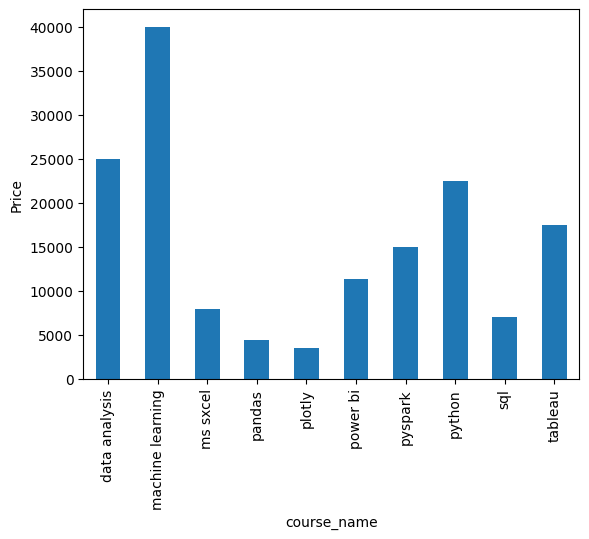

In [20]:
course_wise_revenue = regs.merge(courses , how = 'inner' , on = 'course_id').groupby('course_name')['price'].sum().plot(kind = 'bar')

# 4. setting y-axis label as 'Price' with 'set_ylabel('name')
course_wise_revenue.set_ylabel('Price')

In [21]:
# 5. find students who enrolled in both nov and dec months
common_stud_id = np.intersect1d(nov['student_id'] , dec['student_id'])    # fetching common students in 'nov' and 'dec' months using 'np.intersect1d' numpy function coz both nov['student_id'] and dec['student_id'] are series hence 'np.intersect1d()' works on series only
common_stud_id

students[students['student_id'].isin(common_stud_id)]                     # fetching details of students using 'Boolean masking'

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [22]:
# 6. find course that got no enrollment
course_id_list = np.setdiff1d(courses['course_id'] , regs['course_id'])     # this is set difference as (A - B) = only A -> where A is 'courses' and B is 'regs'

courses[courses['course_id'].isin(course_id_list)]                          # checking 'course_id' are in 'course_id_list' series or not and then fetching those courses using 'Boolean Masking'

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [23]:
# 7. find students who did not enroll into any courses and then find the percentage
students_list = np.setdiff1d(students['student_id'] , regs['student_id'])             # students who did not enroll into any course

display(students[students['student_id'].isin(students_list)])                         # fetching non-enrolled stduents


# to find percentage:
(students[students['student_id'].isin(students_list)].shape[0] / 24) * 100            # shape[0] -> students who did not enroll , '7' number of students who did not enroll and total number of students = '24'

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11


29.166666666666668

# ✅ Self-Join

In [24]:
# 8. Print student name -> partner name for all enrolled students
students.merge(students , how = 'inner' , left_on = 'partner' , right_on = 'student_id')[['name_x' , 'name_y']]      # 'self-join' using 'students.merge(students)'

# left_on  = 'partner'     : used to match the partner's id from first 'students' DataFrame
# right_on = 'student_id'  : used to match the student_id from second 'students' DataFrame with partner's id in first 'students' DataFrame

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [25]:
# 9. find the top 3 students who did most number of enrollments
enrollment_counts = regs.merge(students , on = 'student_id' , how = 'inner').groupby(['student_id' , 'name']).count()     # fetching stundents enrolled in number of courses then count() function will be applied on numerical columns like 'course_id' and 'partner'
top_3_students = enrollment_counts.sort_values(by='course_id', ascending = False).head(3)                                 # fetching top 3 students
display(top_3_students)

,,course_id,partner
student_id,name,,
23,Chhavi Lachman,6,6
7,Tarun Thaker,5,5
14,Pranab Natarajan,4,4


In [26]:
# 10. find top 3 students who spent most amount of money on courses
students_with_enrollment = regs.merge(students , on = 'student_id' , how = 'inner').merge(courses , on = 'course_id')                      # students who enrolled in courses
top_3_students = students_with_enrollment.groupby(['student_id' , 'name'])['price'].sum().sort_values(ascending = False).head(3)           # groupby on 'student_id' and 'name'
display(top_3_students)

,,price
student_id,name,
23,Chhavi Lachman,22594
14,Pranab Natarajan,15096
19,Qabeel Raman,13498


# Alternate syntax for 'merge':
 - pd.merge(df1 , df2 , on , how)

In [27]:
pd.merge(students , regs , on = 'student_id' , how = 'inner')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


## Questions on IPL Dataset

In [28]:
# find top 3 stadiums with highest sixes/match ratio

# merge the delivery and matches DataFrame
temp_df = delivery.merge(matches , left_on = 'match_id' , right_on = 'id')

# only those rows having sixes as batsman runs
six_df = temp_df[temp_df['batsman_runs'] == 6]

# stadiums with sixes count
num_sixes = six_df.groupby('venue')['venue'].count()

# mathces in a particular stadium
num_matches = matches['venue'].value_counts()

# ratio -> sixes/match in a stadium
(num_sixes / num_matches).sort_values(ascending = False).head(3)

'''
Note : 'num_sixes' and 'num_matches' are both series and when we divide both of them , Pandas automatically aligns the data based on their indices i.e. venue/stadium names.
So, the number of sixes for 'Wankhede Stadium' is divided by the number of matches for 'Wankhede Stadium', and so on for every other venue.
'''

,0
venue,
Holkar Cricket Stadium,17.600000
M Chinnaswamy Stadium,13.227273
Sharjah Cricket Stadium,12.666667


In [29]:
temp_df = matches.merge(delivery , left_on = 'id' , right_on = 'match_id').groupby(['season' , 'batsman'])['batsman_runs'].sum()

# now reset_index() to make single index from above multi-index series made by 'season' and 'batsman' and then sort on basis on 'batsman_runs' column and then drop duplicate values for 'season' column and keep only first value
temp_df.reset_index().sort_values('batsman_runs' , ascending = False).drop_duplicates(subset = ['season'] , keep = 'first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
